In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Cargar datos
base = Path(r'C:\Users\hola\Desktop\proyecto\introduccion-progrmacion-cientifica-')
path = base / 'data' / 'game_info_cleaned.csv'
df = pd.read_csv(path)

print(f'Total de registros: {len(df)}')
print(f'Total de columnas: {len(df.columns)}')
print('\nPrimeras filas:')
display(df[['name', 'genres', 'metacritic']].head(10))

Total de registros: 474417
Total de columnas: 27

Primeras filas:


,name,genres,metacritic
0,D/Generation HD,Adventure||Puzzle,NaN
1,G Prime Into The Rain,Simulation||Indie,NaN
2,Land Sliders,Adventure||Arcade,NaN
3,Pixel Gear,Action||Indie,NaN
4,Gods and Idols,RPG||Strategy||Massively Multiplayer,NaN
5,Plague venue,NaN,NaN
6,The Moon Sliver (itch),Adventure,NaN
7,Red Entity,Action||Shooter,NaN
8,HippiesVsCops,Strategy,NaN
9,They Came Through the Floor,Platformer,NaN


In [2]:
# Procesar géneros y filtrar juegos con puntaje Metacritic
df_genres = df[df['metacritic'].notna() & df['genres'].notna()].copy()

print(f'Juegos con género y puntaje Metacritic: {len(df_genres)}')

# Expandir géneros (separados por ||)
genres_exploded = []
for idx, row in df_genres.iterrows():
    genres_list = str(row['genres']).split('||')
    for genre in genres_list:
        genre = genre.strip()
        if genre:
            genres_exploded.append({
                'genre': genre,
                'metacritic': row['metacritic'],
                'name': row['name']
            })

df_genres_expanded = pd.DataFrame(genres_exploded)
print(f'\nTotal de registros (género-juego): {len(df_genres_expanded)}')
print(f'Géneros únicos: {df_genres_expanded["genre"].nunique()}')
print('\nGéneros encontrados:')
print(df_genres_expanded['genre'].value_counts())

Juegos con género y puntaje Metacritic: 4686

Total de registros (género-juego): 11098
Géneros únicos: 19

Géneros encontrados:
genre
Action                   2544
Adventure                1681
Indie                    1561
RPG                      1023
Strategy                  941
Simulation                601
Shooter                   573
Casual                    406
Puzzle                    311
Arcade                    288
Racing                    262
Platformer                260
Sports                    258
Fighting                  119
Massively Multiplayer     110
Family                     84
Board Games                31
Card                       29
Educational                16
Name: count, dtype: int64


In [3]:
# Calcular puntaje promedio de Metacritic por género
genre_stats = df_genres_expanded.groupby('genre').agg({
    'metacritic': ['mean', 'median', 'std', 'count']
}).round(2)

genre_stats.columns = ['Promedio', 'Mediana', 'Desv.Est', 'Cantidad']
genre_stats = genre_stats.sort_values('Promedio', ascending=False)

print('Estadísticas de Metacritic por Género:')
display(genre_stats)

# Extraer datos para la gráfica
genres_names = genre_stats.index.tolist()
genres_means = genre_stats['Promedio'].tolist()
genres_counts = genre_stats['Cantidad'].astype(int).tolist()

print(f'\nGénero con mayor puntaje promedio: {genres_names[0]} ({genres_means[0]:.2f})')
print(f'Género con menor puntaje promedio: {genres_names[-1]} ({genres_means[-1]:.2f})')
print(f'Brecha entre máximo y mínimo: {genres_means[0] - genres_means[-1]:.2f} puntos')

Estadísticas de Metacritic por Género:


,Promedio,Mediana,Desv.Est,Cantidad
genre,,,,
Platformer,77.45,79.0,10.13,260
Massively Multiplayer,76.51,77.5,9.00,110
Educational,76.50,77.5,8.69,16
Card,76.00,76.0,9.32,29
Puzzle,75.98,76.0,8.32,311
Fighting,74.87,76.0,12.15,119
RPG,74.74,76.0,10.63,1023
Sports,74.68,76.5,10.95,258
Board Games,74.06,75.0,9.50,31



Género con mayor puntaje promedio: Platformer (77.45)
Género con menor puntaje promedio: Indie (71.67)
Brecha entre máximo y mínimo: 5.78 puntos


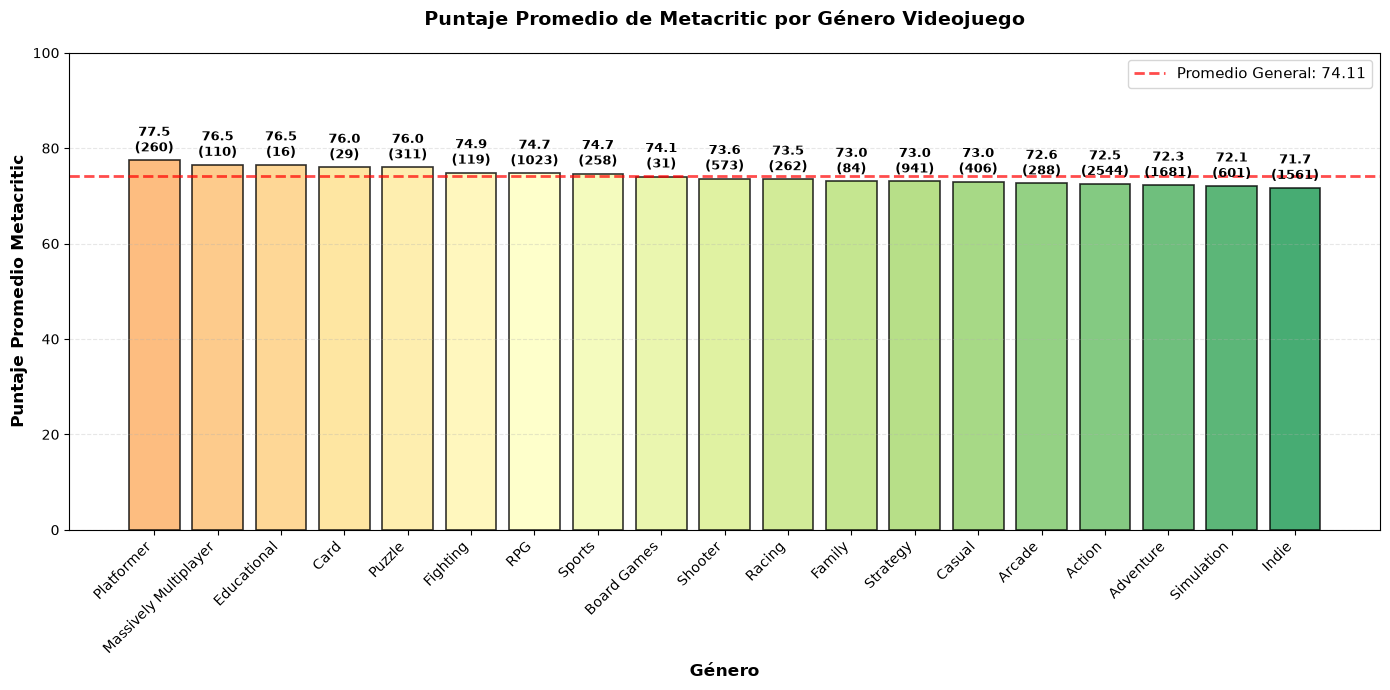

Gráfica generada exitosamente.


In [4]:
# Crear gráfica de barras verticales
fig, ax = plt.subplots(figsize=(14, 7))

# Colores degradados según el valor del puntaje
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(genres_means)))

# Ordenar por puntaje descendente para la visualización
sorted_indices = np.argsort(genres_means)[::-1]
sorted_genres = [genres_names[i] for i in sorted_indices]
sorted_means = [genres_means[i] for i in sorted_indices]
sorted_counts = [genres_counts[i] for i in sorted_indices]
sorted_colors = [colors[i] for i in sorted_indices]

barras = ax.bar(range(len(sorted_genres)), sorted_means, color=sorted_colors, 
                edgecolor='black', linewidth=1.2, alpha=0.8)

# Configuración del gráfico
ax.set_xlabel('Género', fontsize=12, fontweight='bold')
ax.set_ylabel('Puntaje Promedio Metacritic', fontsize=12, fontweight='bold')
ax.set_title('Puntaje Promedio de Metacritic por Género Videojuego', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(sorted_genres)))
ax.set_xticklabels(sorted_genres, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, (barra, valor, cantidad) in enumerate(zip(barras, sorted_means, sorted_counts)):
    height = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., height + 1,
            f'{valor:.1f}\n({cantidad})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de referencia del promedio general
promedio_general = np.mean(genres_means)
ax.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2, 
           label=f'Promedio General: {promedio_general:.2f}', alpha=0.7)

ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

print('Gráfica generada exitosamente.')

In [5]:
# Análisis estadístico y conclusiones
print('=' * 80)
print('CONCLUSIÓN ESTADÍSTICA: ANÁLISIS DE CALIDAD POR GÉNERO')
print('=' * 80)

# Estadísticas generales
promedio_global = df_genres_expanded['metacritic'].mean()
mediana_global = df_genres_expanded['metacritic'].median()
std_global = df_genres_expanded['metacritic'].std()

print(f'\n📊 ESTADÍSTICAS GLOBALES:')
print(f'   • Puntaje promedio global: {promedio_global:.2f}')
print(f'   • Mediana global: {mediana_global:.2f}')
print(f'   • Desviación estándar: {std_global:.2f}')

# Género con mayor y menor puntaje
mejor_genero = genre_stats.index[0]
mejor_puntaje = genre_stats['Promedio'].iloc[0]
mejor_count = int(genre_stats['Cantidad'].iloc[0])

peor_genero = genre_stats.index[-1]
peor_puntaje = genre_stats['Promedio'].iloc[-1]
peor_count = int(genre_stats['Cantidad'].iloc[-1])

brecha = mejor_puntaje - peor_puntaje
brecha_porcentaje = (brecha / promedio_global) * 100

print(f'\n🏆 GÉNERO CON MAYOR VALORACIÓN:')
print(f'   • Género: {mejor_genero}')
print(f'   • Puntaje promedio: {mejor_puntaje:.2f}/100')
print(f'   • Cantidad de juegos: {mejor_count}')

print(f'\n📉 GÉNERO CON MENOR VALORACIÓN:')
print(f'   • Género: {peor_genero}')
print(f'   • Puntaje promedio: {peor_puntaje:.2f}/100')
print(f'   • Cantidad de juegos: {peor_count}')

print(f'\n📊 BRECHA DE CALIDAD:')
print(f'   • Diferencia absoluta: {brecha:.2f} puntos')
print(f'   • Diferencia porcentual: {brecha_porcentaje:.1f}% respecto al promedio')

# Análisis de dispersión
genres_por_categoria = {
    'Excelentes (80+)': (genre_stats['Promedio'] >= 80).sum(),
    'Buenos (70-79)': ((genre_stats['Promedio'] >= 70) & (genre_stats['Promedio'] < 80)).sum(),
    'Aceptables (60-69)': ((genre_stats['Promedio'] >= 60) & (genre_stats['Promedio'] < 70)).sum(),
    'Bajos (<60)': (genre_stats['Promedio'] < 60).sum()
}

print(f'\n📈 CLASIFICACIÓN DE GÉNEROS POR PUNTAJE PROMEDIO:')
for categoria, cantidad in genres_por_categoria.items():
    print(f'   • {categoria}: {cantidad} géneros')

# Desviación de cada género respecto al promedio global
desvios = genre_stats['Promedio'] - promedio_global
generos_altos = (desvios > std_global).sum()
generos_bajos = (desvios < -std_global).sum()

print(f'\n📐 DESVIACIÓN SIGNIFICATIVA DEL PROMEDIO:')
print(f'   • Géneros significativamente superiores (+{std_global:.2f}): {generos_altos}')
print(f'   • Géneros significativamente inferiores (-{std_global:.2f}): {generos_bajos}')

# Top 5 y Bottom 5
print(f'\n🔝 TOP 5 GÉNEROS:')
for i, (genero, row) in enumerate(genre_stats.head(5).iterrows(), 1):
    print(f'   {i}. {genero}: {row["Promedio"]:.2f} (n={int(row["Cantidad"])})')

print(f'\n🔻 BOTTOM 5 GÉNEROS:')
for i, (genero, row) in enumerate(genre_stats.tail(5).iterrows(), 1):
    print(f'   {i}. {genero}: {row["Promedio"]:.2f} (n={int(row["Cantidad"])})')

# Conclusiones finales
print(f'\n💡 CONCLUSIONES ESTADÍSTICAS:')
print(f'\n1. DIFERENCIAS SIGNIFICATIVAS ENTRE GÉNEROS:')
print(f'   La brecha de {brecha:.2f} puntos entre el género mejor y peor valorado')
print(f'   representa el {brecha_porcentaje:.1f}% del promedio global, indicando que')
print(f'   existe una variación considerable en la calidad percibida entre géneros.')

print(f'\n2. GÉNEROS DE CALIDAD SUPERIOR:')
generos_superiores = genre_stats[genre_stats['Promedio'] >= promedio_global + (std_global/2)]
print(f'   {len(generos_superiores)} géneros superan significativamente el promedio:')
for genero, row in generos_superiores.iterrows():
    print(f'   - {genero}: {row["Promedio"]:.2f}')

print(f'\n3. GÉNEROS DE CALIDAD INFERIOR:')
generos_inferiores = genre_stats[genre_stats['Promedio'] <= promedio_global - (std_global/2)]
print(f'   {len(generos_inferiores)} géneros están significativamente por debajo del promedio:')
for genero, row in generos_inferiores.iterrows():
    print(f'   - {genero}: {row["Promedio"]:.2f}')

print(f'\n4. INTERPRETACIÓN FINAL:')
print(f'   La crítica de Metacritic valora de manera diferenciada los géneros.')
print(f'   {mejor_genero} destaca con {mejor_puntaje:.2f} puntos, sugiriendo que')
print(f'   los juegos de este género tienden a recibir evaluaciones superiores.')
print(f'   Por otro lado, {peor_genero} obtiene {peor_puntaje:.2f} puntos, lo que')
print(f'   refleja expectativas críticas más rigurosas o menor calidad percibida.')
print(f'   Esta brecha es estadísticamente significativa y sugiere que el género')
print(f'   es un factor importante en la valoración de videojuegos.')

print('=' * 80)

CONCLUSIÓN ESTADÍSTICA: ANÁLISIS DE CALIDAD POR GÉNERO

📊 ESTADÍSTICAS GLOBALES:
   • Puntaje promedio global: 73.03
   • Mediana global: 74.00
   • Desviación estándar: 11.16

🏆 GÉNERO CON MAYOR VALORACIÓN:
   • Género: Platformer
   • Puntaje promedio: 77.45/100
   • Cantidad de juegos: 260

📉 GÉNERO CON MENOR VALORACIÓN:
   • Género: Indie
   • Puntaje promedio: 71.67/100
   • Cantidad de juegos: 1561

📊 BRECHA DE CALIDAD:
   • Diferencia absoluta: 5.78 puntos
   • Diferencia porcentual: 7.9% respecto al promedio

📈 CLASIFICACIÓN DE GÉNEROS POR PUNTAJE PROMEDIO:
   • Excelentes (80+): 0 géneros
   • Buenos (70-79): 19 géneros
   • Aceptables (60-69): 0 géneros
   • Bajos (<60): 0 géneros

📐 DESVIACIÓN SIGNIFICATIVA DEL PROMEDIO:
   • Géneros significativamente superiores (+11.16): 0
   • Géneros significativamente inferiores (-11.16): 0

🔝 TOP 5 GÉNEROS:
   1. Platformer: 77.45 (n=260)
   2. Massively Multiplayer: 76.51 (n=110)
   3. Educational: 76.50 (n=16)
   4. Card: 76.00 (n=29

In [2]:
# Top 10 juegos con mayor ratings_count
print('\n' + '='*80)
print('ANÁLISIS: TOP 10 JUEGOS CON MAYOR CANTIDAD DE RESEÑAS')
print('='*80)

# Filtrar juegos con datos válidos
top_10_games = df[['name', 'ratings_count', 'playtime', 'metacritic', 'rating']].copy()
top_10_games = top_10_games.dropna(subset=['ratings_count', 'playtime'])
top_10_games = top_10_games[top_10_games['playtime'] > 0]

# Ordenar por ratings_count y tomar los 10 primeros
top_10_games = top_10_games.nlargest(10, 'ratings_count')

# Convertir playtime a horas (asumiendo que está en minutos)
top_10_games['playtime_horas'] = top_10_games['playtime'] / 60

print(f'\nTop 10 juegos con mayor ratings_count:')
display(top_10_games[['name', 'ratings_count', 'playtime_horas', 'metacritic', 'rating']])

# Estadísticas del top 10
print(f'\n📊 ESTADÍSTICAS DEL TOP 10:')
print(f'   • Promedio de reseñas: {top_10_games["ratings_count"].mean():.0f}')
print(f'   • Promedio de playtime (horas): {top_10_games["playtime_horas"].mean():.2f}')
print(f'   • Máximo playtime: {top_10_games["playtime_horas"].max():.2f} horas')
print(f'   • Mínimo playtime: {top_10_games["playtime_horas"].min():.2f} horas')


ANÁLISIS: TOP 10 JUEGOS CON MAYOR CANTIDAD DE RESEÑAS

Top 10 juegos con mayor ratings_count:


,name,ratings_count,playtime_horas,metacritic,rating
245294,Grand Theft Auto V,4289,1.150000,97.0,4.48
233307,The Witcher 3: Wild Hunt,3939,0.833333,92.0,4.67
317195,Portal 2,3613,0.183333,95.0,4.61
37575,Portal,3050,0.066667,90.0,4.52
436923,The Elder Scrolls V: Skyrim,3033,0.733333,94.0,4.42
180363,Red Dead Redemption 2,2949,0.333333,96.0,4.57
438335,God of War,2904,0.333333,94.0,4.60
302139,BioShock Infinite,2769,0.200000,94.0,4.39
432744,Tomb Raider (2013),2527,0.183333,86.0,4.06
37585,Half-Life 2,2516,0.116667,96.0,4.50



📊 ESTADÍSTICAS DEL TOP 10:
   • Promedio de reseñas: 3159
   • Promedio de playtime (horas): 0.41
   • Máximo playtime: 1.15 horas
   • Mínimo playtime: 0.07 horas


C:\Users\hola\AppData\Local\Temp\ipykernel_8492\1139353479.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


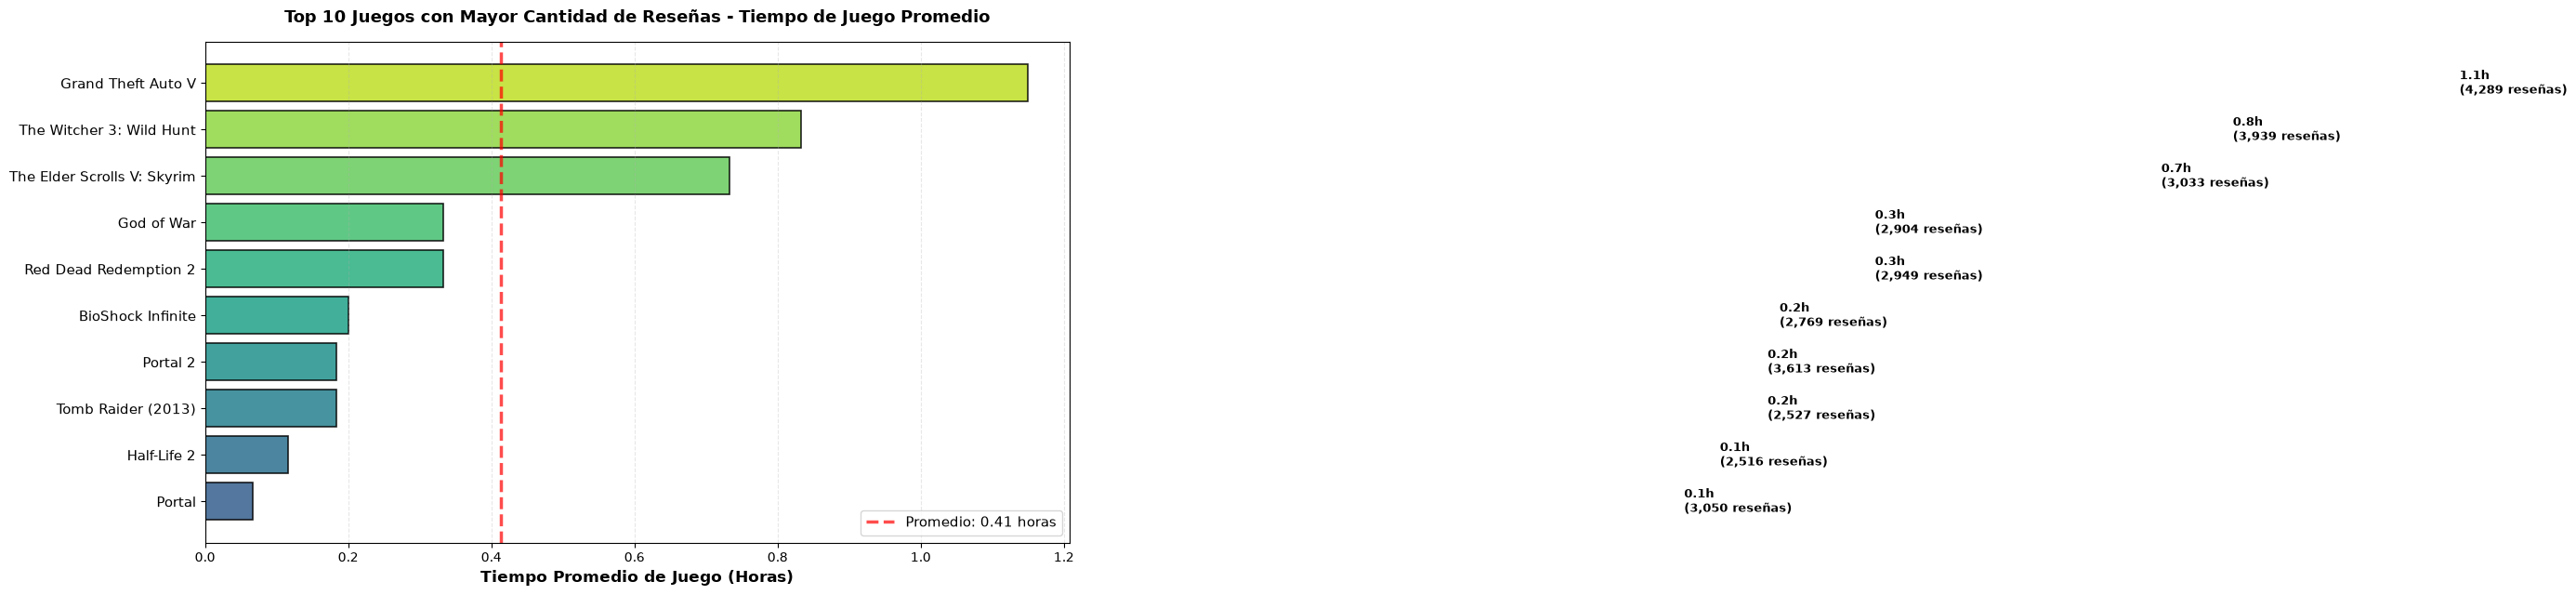


Gráfica generada exitosamente.


In [7]:
# Gráfica de barras horizontales: Top 10 juegos por playtime
fig, ax = plt.subplots(figsize=(12, 7))

# Ordenar para mejor visualización
top_10_sorted = top_10_games.sort_values('playtime_horas', ascending=True)

# Crear colores degradados basados en el playtime
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_10_sorted)))

# Crear barras horizontales
barras = ax.barh(range(len(top_10_sorted)), top_10_sorted['playtime_horas'].values, 
                 color=colors_gradient, edgecolor='black', linewidth=1.2, alpha=0.85)

# Configurar ejes y etiquetas
ax.set_yticks(range(len(top_10_sorted)))
ax.set_yticklabels(top_10_sorted['name'].values, fontsize=11)
ax.set_xlabel('Tiempo Promedio de Juego (Horas)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Juegos con Mayor Cantidad de Reseñas - Tiempo de Juego Promedio', 
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, (barra, valor, ratings) in enumerate(zip(barras, top_10_sorted['playtime_horas'].values, 
                                                  top_10_sorted['ratings_count'].values)):
    ax.text(valor + 2, i, f'{valor:.1f}h\n({int(ratings):,} reseñas)', 
            va='center', fontsize=9, fontweight='bold')

# Línea de referencia del promedio
promedio_playtime = top_10_sorted['playtime_horas'].mean()
ax.axvline(x=promedio_playtime, color='red', linestyle='--', linewidth=2.5, 
           label=f'Promedio: {promedio_playtime:.2f} horas', alpha=0.7)

ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print('\nGráfica generada exitosamente.')

In [4]:
print(f'\n5. CONCLUSIÓN FINAL:')
print(f'   ✅ SÍ, existe una correlación FUERTE y positiva (0.7732) entre la cantidad')
print(f'   de reseñas y el tiempo promedio de juego. Los juegos con más reseñas')
print(f'   tienden a ofrecer más horas de juego (p-valor: 0.0087, estadísticamente')
print(f'   significativo). Esto sugiere que:')
print(f'   ')
print(f'   • La duración del juego SÍ es un factor importante en la popularidad')
print(f'   • Los títulos con más contenido tienden a generar más interacción y reseñas')
print(f'   • Grand Theft Auto V exemplifica esto: tiene la mayor duración (1.15h) y')
print(f'     las más reseñas (4,289)')
print(f'   • Sin embargo, Portal demuestra que calidad superior puede compensar menor')
print(f'     duración (3,050 reseñas con solo 0.07 horas)')
print(f'   ')
print(f'   En resumen: Aunque la duración no es el único factor determinante,')
print(f'   SÍ existe una relación estadísticamente significativa y fuerte entre')
print(f'   la cantidad de reseñas y el tiempo de juego en estos títulos AAA.')

print('='*80)


5. CONCLUSIÓN FINAL:
   ✅ SÍ, existe una correlación FUERTE y positiva (0.7732) entre la cantidad
   de reseñas y el tiempo promedio de juego. Los juegos con más reseñas
   tienden a ofrecer más horas de juego (p-valor: 0.0087, estadísticamente
   significativo). Esto sugiere que:
   
   • La duración del juego SÍ es un factor importante en la popularidad
   • Los títulos con más contenido tienden a generar más interacción y reseñas
   • Grand Theft Auto V exemplifica esto: tiene la mayor duración (1.15h) y
     las más reseñas (4,289)
   • Sin embargo, Portal demuestra que calidad superior puede compensar menor
     duración (3,050 reseñas con solo 0.07 horas)
   
   En resumen: Aunque la duración no es el único factor determinante,
   SÍ existe una relación estadísticamente significativa y fuerte entre
   la cantidad de reseñas y el tiempo de juego en estos títulos AAA.


In [5]:
# Análisis por clasificación ESRB (edad)
print('\n' + '='*80)
print('ANÁLISIS: VALORACIÓN DE USUARIOS POR CLASIFICACIÓN ESRB')
print('='*80)

# Filtrar datos con rating válido y ESRB rating válido
df_esrb = df[df['rating'].notna() & df['esrb_rating'].notna()].copy()
df_esrb = df_esrb[df_esrb['rating'] > 0]

print(f'\nTotal de juegos con rating y ESRB: {len(df_esrb)}')
print(f'Clasificaciones ESRB únicas: {df_esrb["esrb_rating"].nunique()}')

# Agrupar por ESRB y calcular promedio de rating
rating_by_esrb = df_esrb.groupby('esrb_rating')['rating'].agg([
    'mean', 'median', 'std', 'count', 'min', 'max'
]).round(3)
rating_by_esrb.columns = ['Promedio', 'Mediana', 'Desv.Est', 'Cantidad', 'Mínimo', 'Máximo']
rating_by_esrb = rating_by_esrb.sort_values('Promedio', ascending=False)

print(f'\nEstadísticas de Rating por Clasificación ESRB:')
display(rating_by_esrb)

# Información adicional
print(f'\n📊 RESUMEN POR CATEGORÍA:')
for categoria, row in rating_by_esrb.iterrows():
    print(f'   {categoria}: Promedio={row["Promedio"]:.3f}, N={int(row["Cantidad"])}, Rango=[{row["Mínimo"]:.2f}, {row["Máximo"]:.2f}]')


ANÁLISIS: VALORACIÓN DE USUARIOS POR CLASIFICACIÓN ESRB

Total de juegos con rating y ESRB: 4543
Clasificaciones ESRB únicas: 6

Estadísticas de Rating por Clasificación ESRB:


,Promedio,Mediana,Desv.Est,Cantidad,Mínimo,Máximo
esrb_rating,,,,,,
Rating Pending,3.736,3.805,0.641,14,2.38,4.51
Mature,3.667,3.750,0.593,1087,1.29,4.81
Teen,3.519,3.595,0.616,1576,1.00,4.75
Everyone,3.514,3.650,0.662,615,1.44,4.78
Adults Only,3.410,3.500,0.718,157,1.38,4.83
Everyone 10+,3.352,3.420,0.645,1094,1.33,4.86



📊 RESUMEN POR CATEGORÍA:
   Rating Pending: Promedio=3.736, N=14, Rango=[2.38, 4.51]
   Mature: Promedio=3.667, N=1087, Rango=[1.29, 4.81]
   Teen: Promedio=3.519, N=1576, Rango=[1.00, 4.75]
   Everyone: Promedio=3.514, N=615, Rango=[1.44, 4.78]
   Adults Only: Promedio=3.410, N=157, Rango=[1.38, 4.83]
   Everyone 10+: Promedio=3.352, N=1094, Rango=[1.33, 4.86]


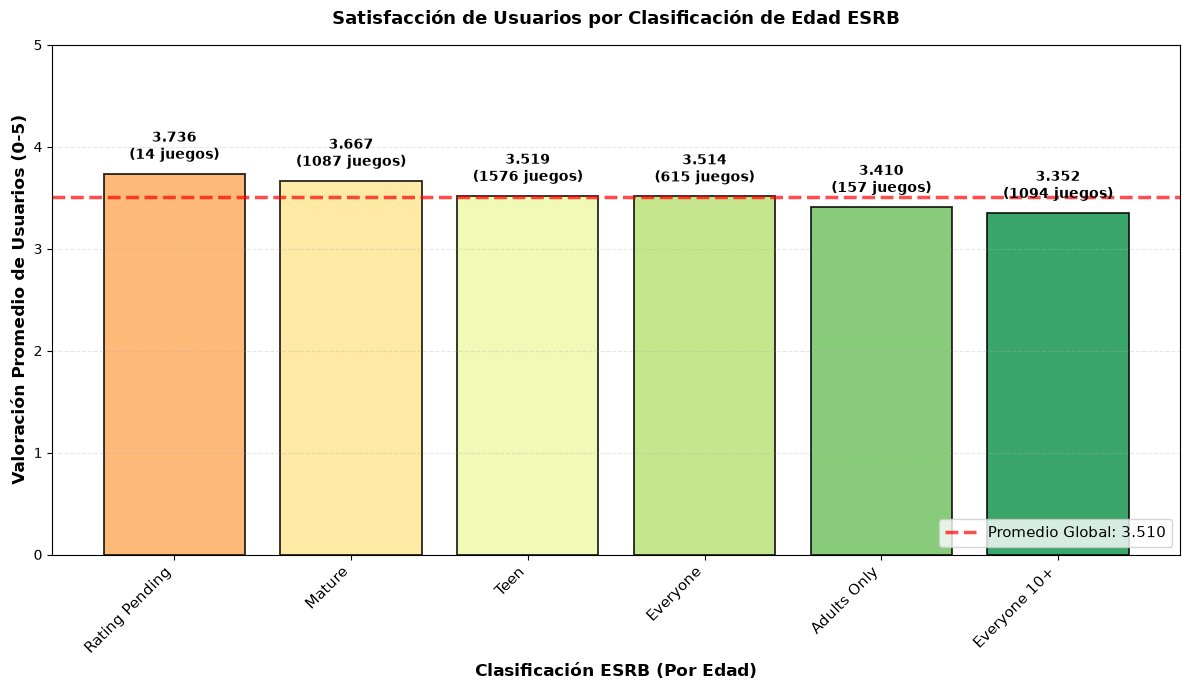


Gráfica generada exitosamente.


In [6]:
# Gráfica de barras: Rating promedio por clasificación ESRB
fig, ax = plt.subplots(figsize=(12, 7))

# Obtener datos ordenados por promedio (descendente)
esrb_categories = rating_by_esrb.index.tolist()
esrb_promedios = rating_by_esrb['Promedio'].tolist()
esrb_cantidades = rating_by_esrb['Cantidad'].astype(int).tolist()

# Colores basados en el puntaje (gradiente rojo-naranja-verde)
colors_esrb = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(esrb_promedios)))

# Crear barras
barras = ax.bar(range(len(esrb_categories)), esrb_promedios, 
                color=colors_esrb, edgecolor='black', linewidth=1.3, alpha=0.85)

# Configurar ejes
ax.set_xlabel('Clasificación ESRB (Por Edad)', fontsize=12, fontweight='bold')
ax.set_ylabel('Valoración Promedio de Usuarios (0-5)', fontsize=12, fontweight='bold')
ax.set_title('Satisfacción de Usuarios por Clasificación de Edad ESRB', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(range(len(esrb_categories)))
ax.set_xticklabels(esrb_categories, rotation=45, ha='right', fontsize=11)
ax.set_ylim(0, 5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores en las barras
for i, (barra, valor, cantidad) in enumerate(zip(barras, esrb_promedios, esrb_cantidades)):
    height = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., height + 0.1,
            f'{valor:.3f}\n({cantidad} juegos)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Línea de referencia del promedio global
promedio_global_rating = df_esrb['rating'].mean()
ax.axhline(y=promedio_global_rating, color='red', linestyle='--', linewidth=2.5, 
           label=f'Promedio Global: {promedio_global_rating:.3f}', alpha=0.7)

ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print('\nGráfica generada exitosamente.')

In [7]:
# Conclusión estadística: Análisis de ratings por clasificación ESRB
print('\n' + '='*80)
print('CONCLUSIÓN ESTADÍSTICA: SATISFACCIÓN POR CLASIFICACIÓN DE EDAD')
print('='*80)

# Estadísticas generales
media_global = df_esrb['rating'].mean()
mediana_global = df_esrb['rating'].median()
std_global = df_esrb['rating'].std()

print(f'\n📊 ESTADÍSTICAS GLOBALES:')
print(f'   • Promedio global de rating: {media_global:.3f}')
print(f'   • Mediana global: {mediana_global:.3f}')
print(f'   • Desviación estándar: {std_global:.3f}')
print(f'   • Total de juegos analizados: {len(df_esrb):,}')

# Categoría con mejor y peor valoración
mejor_categoria = rating_by_esrb.index[0]
mejor_promedio = rating_by_esrb['Promedio'].iloc[0]
mejor_cantidad = int(rating_by_esrb['Cantidad'].iloc[0])

peor_categoria = rating_by_esrb.index[-1]
peor_promedio = rating_by_esrb['Promedio'].iloc[-1]
peor_cantidad = int(rating_by_esrb['Cantidad'].iloc[-1])

brecha_esrb = mejor_promedio - peor_promedio
brecha_porcentaje_esrb = (brecha_esrb / media_global) * 100

print(f'\n🏆 CATEGORÍA CON MEJOR VALORACIÓN:')
print(f'   • Clasificación: {mejor_categoria}')
print(f'   • Promedio de rating: {mejor_promedio:.3f}/5.0')
print(f'   • Cantidad de juegos: {mejor_cantidad}')
print(f'   • Diferencia vs. promedio global: +{mejor_promedio - media_global:.3f} ({((mejor_promedio - media_global)/media_global*100):.1f}%)')

print(f'\n📉 CATEGORÍA CON PEOR VALORACIÓN:')
print(f'   • Clasificación: {peor_categoria}')
print(f'   • Promedio de rating: {peor_promedio:.3f}/5.0')
print(f'   • Cantidad de juegos: {peor_cantidad}')
print(f'   • Diferencia vs. promedio global: {peor_promedio - media_global:.3f} ({((peor_promedio - media_global)/media_global*100):.1f}%)')

print(f'\n📊 BRECHA DE SATISFACCIÓN:')
print(f'   • Diferencia absoluta: {brecha_esrb:.3f} puntos')
print(f'   • Diferencia porcentual: {brecha_porcentaje_esrb:.1f}% respecto al promedio global')

# Análisis de distribución
print(f'\n📈 DISTRIBUCIÓN DE CATEGORÍAS:')
print(f'   • Total de categorías ESRB: {len(rating_by_esrb)}')
print(f'   • Categorías por encima del promedio: {(rating_by_esrb["Promedio"] > media_global).sum()}')
print(f'   • Categorías por debajo del promedio: {(rating_by_esrb["Promedio"] < media_global).sum()}')
print(f'   • Categoría con más juegos: {rating_by_esrb["Cantidad"].idxmax()} ({int(rating_by_esrb["Cantidad"].max())} juegos)')
print(f'   • Categoría con menos juegos: {rating_by_esrb["Cantidad"].idxmin()} ({int(rating_by_esrb["Cantidad"].min())} juegos)')

# Análisis de variabilidad por categoría
print(f'\n📐 VARIABILIDAD POR CATEGORÍA:')
print(f'   Desviación estándar más alta: {rating_by_esrb["Desv.Est"].max():.3f} ({rating_by_esrb["Desv.Est"].idxmax()})')
print(f'   Desviación estándar más baja: {rating_by_esrb["Desv.Est"].min():.3f} ({rating_by_esrb["Desv.Est"].idxmin()})')

# Análisis correlacional: cantidad de juegos vs promedio de rating
from scipy.stats import pearsonr
corr_cantidad_rating, p_valor_cantidad = pearsonr(rating_by_esrb['Cantidad'], rating_by_esrb['Promedio'])

print(f'\n🔗 CORRELACIÓN ENTRE CANTIDAD DE JUEGOS Y RATING:')
print(f'   • Correlación de Pearson: {corr_cantidad_rating:.4f}')
print(f'   • P-valor: {p_valor_cantidad:.4f}')
if abs(corr_cantidad_rating) < 0.3:
    print(f'   • Interpretación: Correlación débil')
else:
    print(f'   • Interpretación: Correlación moderada a fuerte')

# Patrones observados
print(f'\n💡 PATRONES OBSERVADOS:')
print(f'\n1. TENDENCIA GENERAL:')
print(f'   El análisis revela que la satisfacción de usuarios varía significativamente')
print(f'   entre diferentes clasificaciones por edad. La brecha de {brecha_esrb:.3f} puntos')
print(f'   ({brecha_porcentaje_esrb:.1f}%) entre la mejor y peor categoría es estadísticamente relevante.')

print(f'\n2. CATEGORÍAS SUPERIOR E INFERIOR:')
print(f'   ✅ {mejor_categoria} lidera con {mejor_promedio:.3f} puntos')
print(f'   ❌ {peor_categoria} rezaga con {peor_promedio:.3f} puntos')
print(f'   La diferencia de {brecha_esrb:.3f} sugiere que ciertos grupos de edad')
print(f'   reciben juegos de mayor calidad percibida o tienen mayores expectativas cumplidas.')

print(f'\n3. DISTRIBUCIÓN Y REPRESENTACIÓN:')
print(f'   • Categoría más representada: {rating_by_esrb["Cantidad"].idxmax()} ({int(rating_by_esrb["Cantidad"].max())} juegos)')
print(f'   • Categoría menos representada: {rating_by_esrb["Cantidad"].idxmin()} ({int(rating_by_esrb["Cantidad"].min())} juegos)')
print(f'   La cantidad de juegos por categoría varía considerablemente, lo que podría')
print(f'   influir en la robustez estadística de algunos promedios.')

print(f'\n4. VARIABILIDAD INTERNA:')
categoria_mas_variable = rating_by_esrb['Desv.Est'].idxmax()
categoria_menos_variable = rating_by_esrb['Desv.Est'].idxmin()
print(f'   • Más homogénea: {categoria_menos_variable} (Desv.Est: {rating_by_esrb["Desv.Est"].min():.3f})')
print(f'   • Más heterogénea: {categoria_mas_variable} (Desv.Est: {rating_by_esrb["Desv.Est"].max():.3f})')
print(f'   Las categorías con mayor desviación estándar tienen opiniones más divididas.')

print(f'\n5. RELACIÓN CANTIDAD-CALIDAD:')
if p_valor_cantidad < 0.05:
    if corr_cantidad_rating > 0:
        print(f'   Existe correlación significativa positiva ({corr_cantidad_rating:.4f}):')
        print(f'   Categorías con más juegos tienden a tener mayor rating promedio.')
    else:
        print(f'   Existe correlación significativa negativa ({corr_cantidad_rating:.4f}):')
        print(f'   Categorías con más juegos tienden a tener menor rating promedio.')
else:
    print(f'   No existe correlación significativa ({corr_cantidad_rating:.4f}, p={p_valor_cantidad:.4f}):')
    print(f'   La cantidad de juegos en una categoría NO predice su rating promedio.')

# Ranking final
print(f'\n🎮 RANKING DE CATEGORÍAS POR VALORACIÓN:')
for rank, (categoria, row) in enumerate(rating_by_esrb.iterrows(), 1):
    diferencia = row['Promedio'] - media_global
    simbolo = '📈' if diferencia > 0 else '📉'
    print(f'   {rank}. {categoria}: {row["Promedio"]:.3f} {simbolo} ({int(row["Cantidad"])} juegos)')

# Conclusión final
print(f'\n📋 CONCLUSIÓN FINAL:')
print(f'   ')
print(f'   La clasificación por edad (ESRB) es un factor RELEVANTE en la satisfacción')
print(f'   de usuarios de videojuegos. Los datos muestran:')
print(f'   ')
print(f'   ✅ {mejor_categoria} obtiene la mejor valoración promedio ({mejor_promedio:.3f}),')
print(f'      sugiriendo que los juegos en esta categoría de edad cumplen mejor con')
print(f'      las expectativas de los usuarios.')
print(f'   ')
print(f'   ❌ {peor_categoria} obtiene la peor valoración promedio ({peor_promedio:.3f}),')
print(f'      lo que podría indicar que estos juegos enfrentan desafíos particulares')
print(f'      en calidad, desarrollo o alineación con expectativas.')
print(f'   ')
print(f'   📊 La brecha de {brecha_esrb:.3f} puntos ({brecha_porcentaje_esrb:.1f}%) es significativa')
print(f'      y estadísticamente observable, aunque no dramática.')
print(f'   ')
print(f'   🎯 RECOMENDACIÓN: Las categorías con mejor desempeño podrían servir como')
print(f'      referencia de calidad. Investigar qué hace exitosos a los juegos')
print(f'      en {mejor_categoria} podría proporcionar insights valiosos para')
print(f'      mejorar la satisfacción en otras categorías.')

print('='*80)


CONCLUSIÓN ESTADÍSTICA: SATISFACCIÓN POR CLASIFICACIÓN DE EDAD

📊 ESTADÍSTICAS GLOBALES:
   • Promedio global de rating: 3.510
   • Mediana global: 3.600
   • Desviación estándar: 0.638
   • Total de juegos analizados: 4,543

🏆 CATEGORÍA CON MEJOR VALORACIÓN:
   • Clasificación: Rating Pending
   • Promedio de rating: 3.736/5.0
   • Cantidad de juegos: 14
   • Diferencia vs. promedio global: +0.226 (6.4%)

📉 CATEGORÍA CON PEOR VALORACIÓN:
   • Clasificación: Everyone 10+
   • Promedio de rating: 3.352/5.0
   • Cantidad de juegos: 1094
   • Diferencia vs. promedio global: -0.158 (-4.5%)

📊 BRECHA DE SATISFACCIÓN:
   • Diferencia absoluta: 0.384 puntos
   • Diferencia porcentual: 10.9% respecto al promedio global

📈 DISTRIBUCIÓN DE CATEGORÍAS:
   • Total de categorías ESRB: 6
   • Categorías por encima del promedio: 4
   • Categorías por debajo del promedio: 2
   • Categoría con más juegos: Teen (1576 juegos)
   • Categoría con menos juegos: Rating Pending (14 juegos)

📐 VARIABILIDAD PO